In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
from pathlib import Path
root_path = Path().resolve().parent.parent
sys.path.append(str(root_path))

from utils.eda import summary_stats, missing_report, outlier_report, class_balance, correlation_matrix
from utils.visualization import *

In [2]:
df = pd.read_csv(root_path / "impact of ai student" / 'data' / 'ai_student_impact_dataset.csv')
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [3]:
summary_stats(df)

SHAPE        : 50000 rows × 16 columns

── DTYPES ──
                              dtype  nunique                 sample
Student_ID                    int64    50000                 100001
Major_Category               object        5             Humanities
Year_of_Study                object        5                 Senior
Pre_Semester_GPA            float64     2389                  2.418
Weekly_GenAI_Hours          float64     3566                  23.31
Primary_Use_Case             object        5   Copywriting/Drafting
Prompt_Engineering_Skill     object        3               Beginner
Tool_Diversity                int64        5                      1
Paid_Subscription              bool        2                   True
Traditional_Study_Hours     float64     2516                   8.13
Perceived_AI_Dependency       int64       10                      5
Institutional_Policy         object        3  Allowed_With_Citation
Anxiety_Level_During_Exams    int64       10                   

In [21]:
df.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


In [4]:
missing_report(df)

MISSING VALUE REPORT  (total kolom: 16)
✓ Tidak ada missing values.


In [5]:
print(f"Jumlah data duplikat: {df.duplicated().sum()}")

Jumlah data duplikat: 0


In [6]:
fitur_numeric = df.select_dtypes(include='number').columns.tolist()
fitur_numeric.remove("Student_ID")
fitur_category = df.select_dtypes(include=['object', 'bool']).columns.tolist()

In [16]:
outlier_report(df)

OUTLIER REPORT  (method=iqr)
                 column  n_outliers  pct_outliers  has_outlier  lower_bound  upper_bound
     Weekly_GenAI_Hours        2583          5.17         True     -11.6050      25.7150
      Post_Semester_GPA         346          0.69         True       1.9359       4.8369
       Pre_Semester_GPA         328          0.66         True       1.8035       4.5515
  Skill_Retention_Score         216          0.43         True      39.2650     112.7450
Perceived_AI_Dependency         190          0.38         True      -2.5000       9.5000
Traditional_Study_Hours         161          0.32         True      -3.1650      25.4350

Kolom dengan outlier: 6 / 9


In [18]:
class_balance(df, 'Burnout_Risk_Level')

CLASS BALANCE — 'Burnout_Risk_Level'
                    count    pct
Burnout_Risk_Level              
Medium              21144  42.29
Low                 16369  32.74
High                12487  24.97

Imbalance ratio (max/min): 1.69x
✓  Dataset relatif balanced.


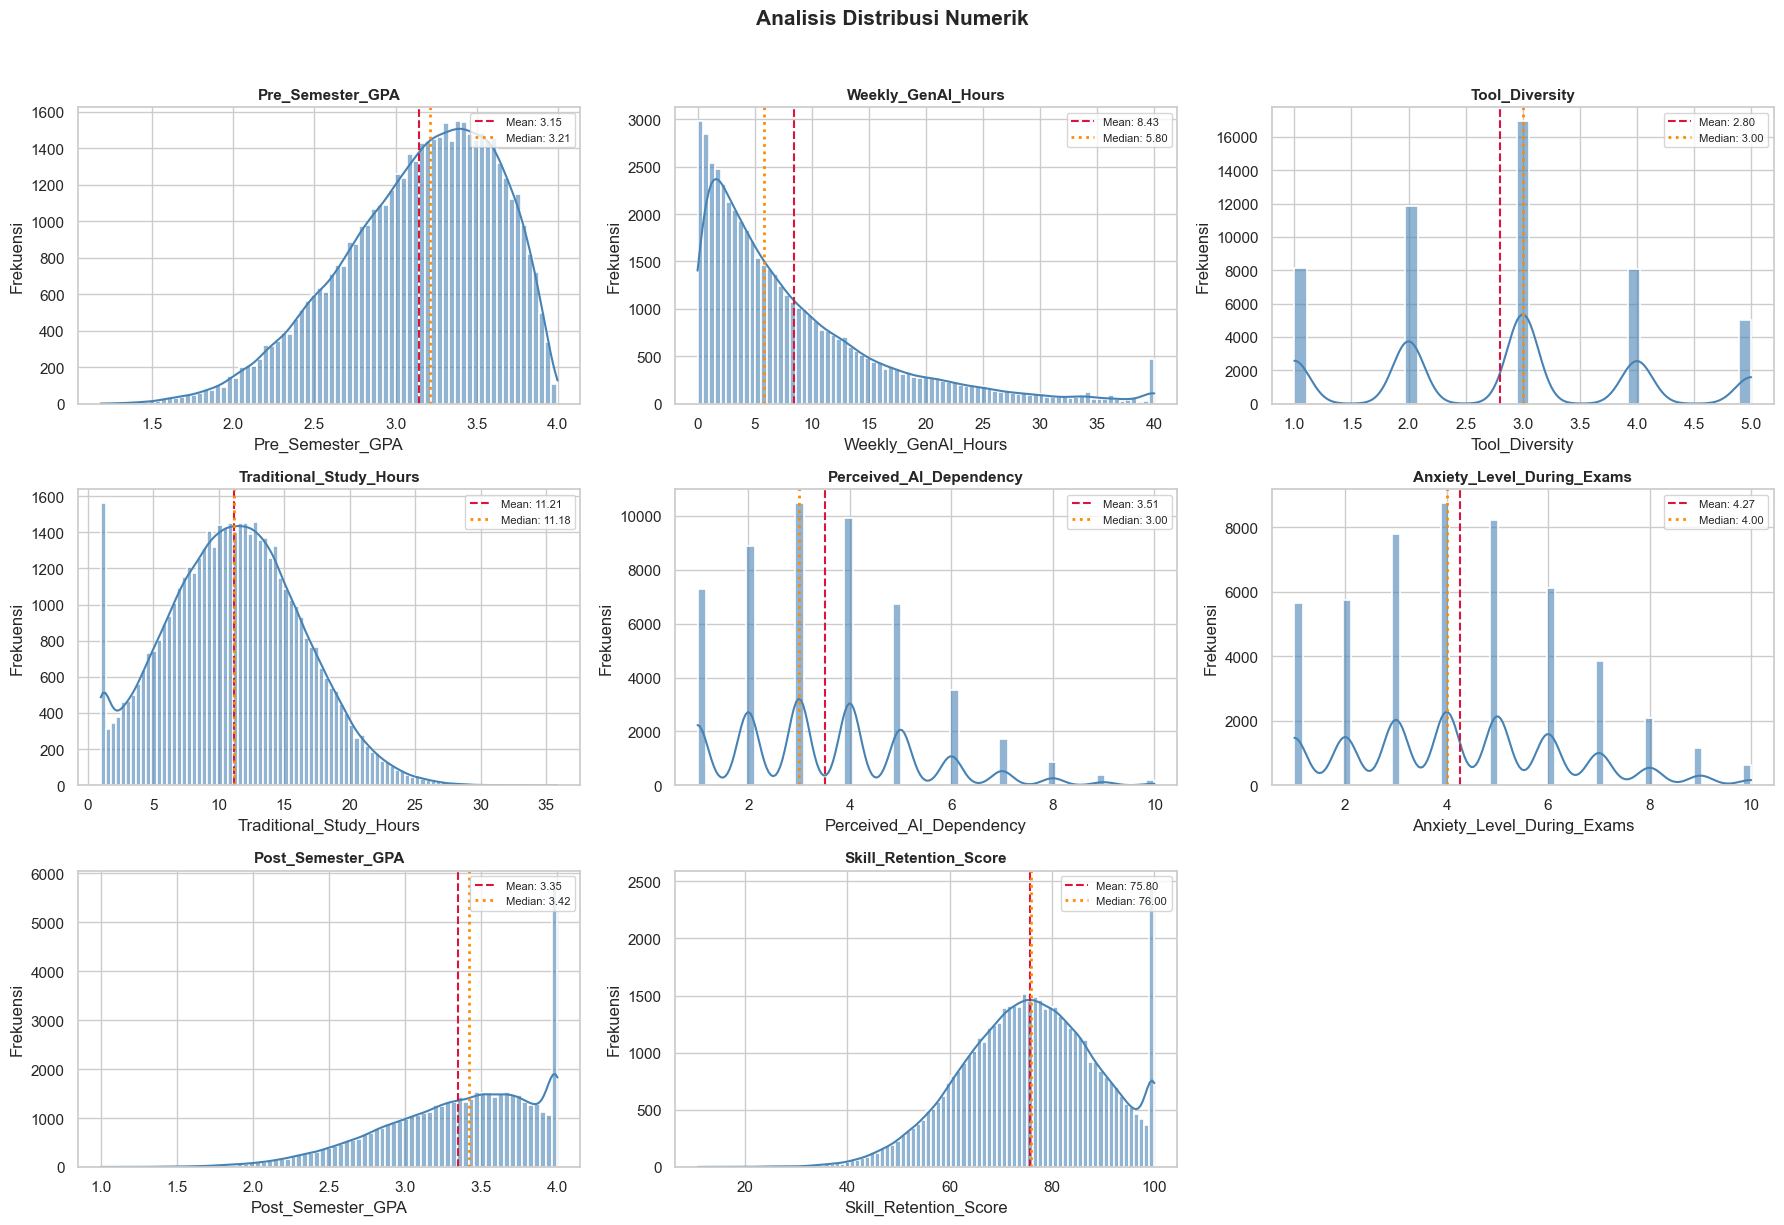

In [7]:
plot_distributions(df, fitur_numeric)

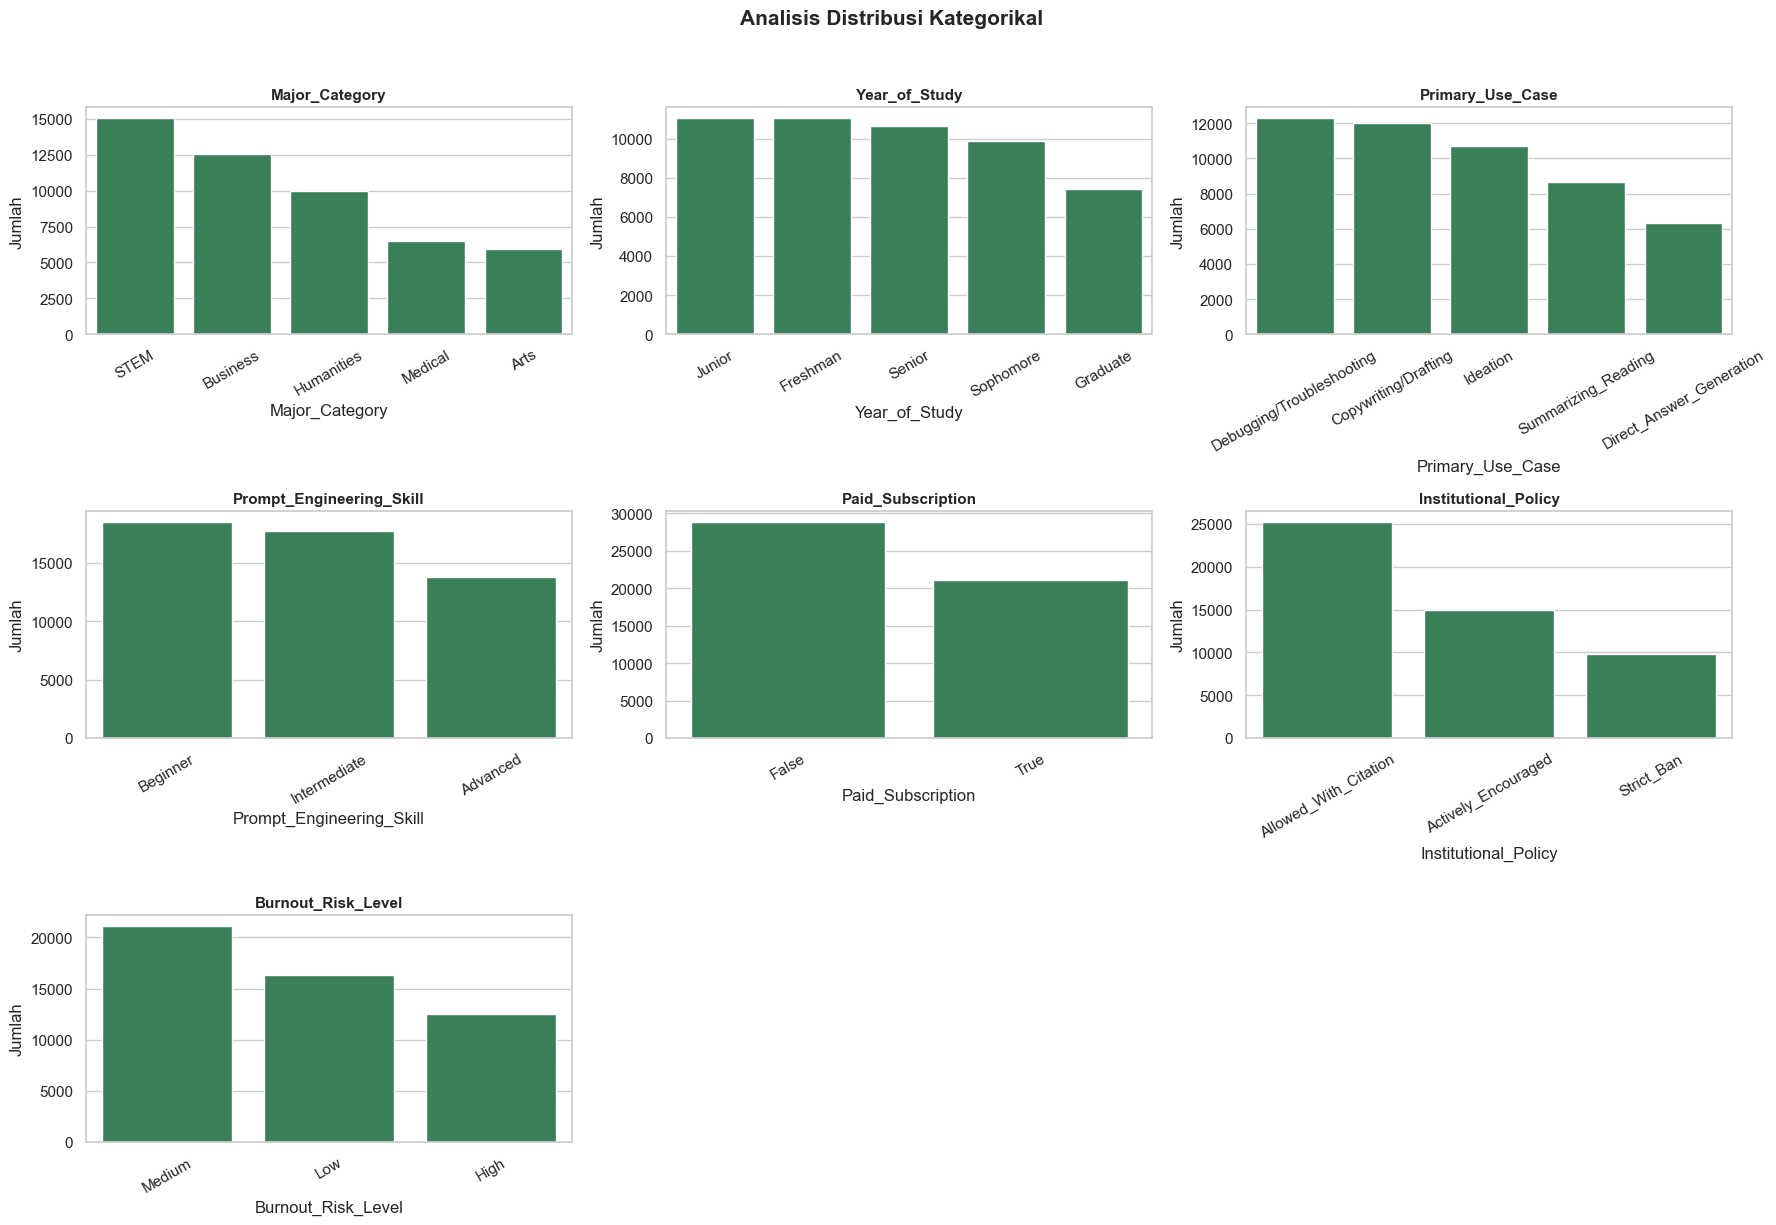

In [8]:
plot_distributions(df, fitur_category)

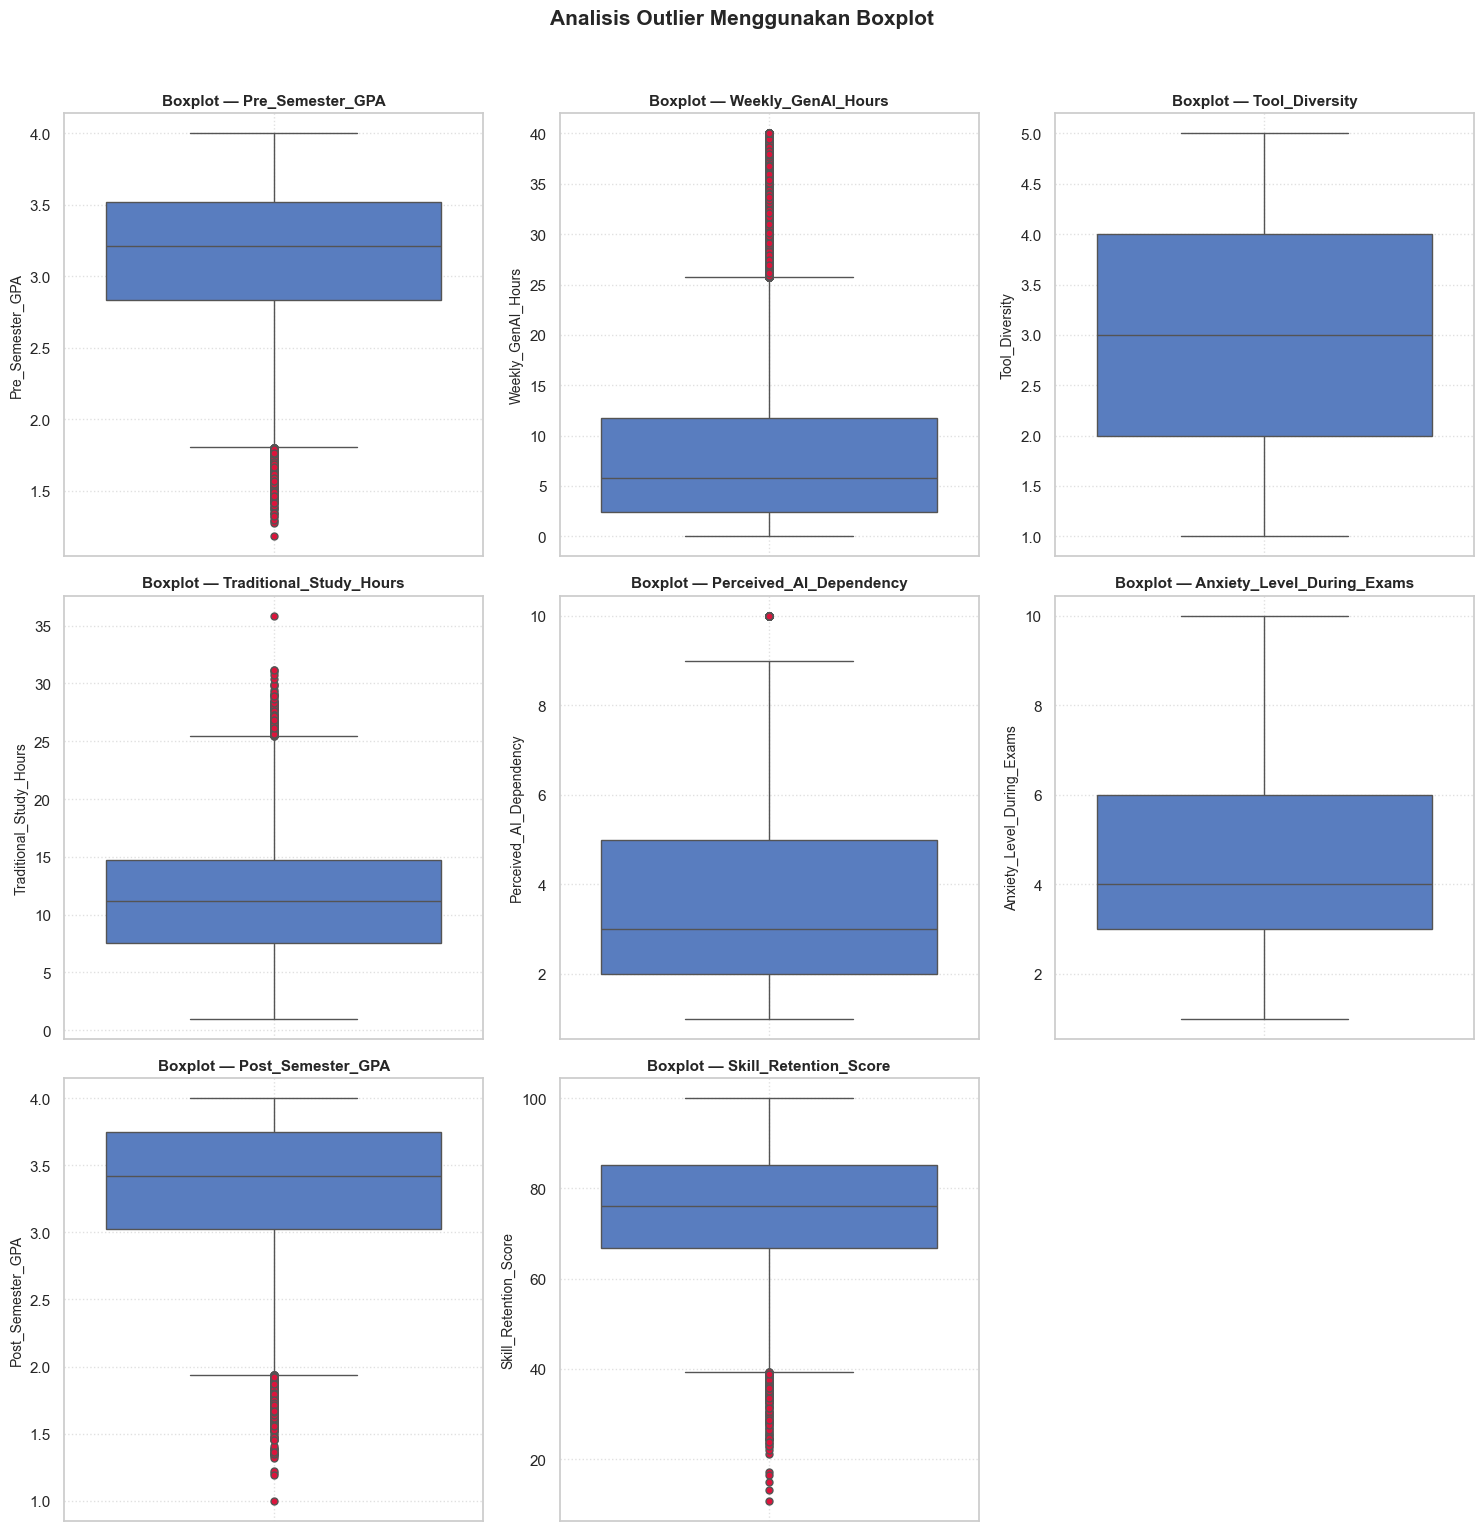

In [19]:
plot_boxplot(df, fitur_numeric)

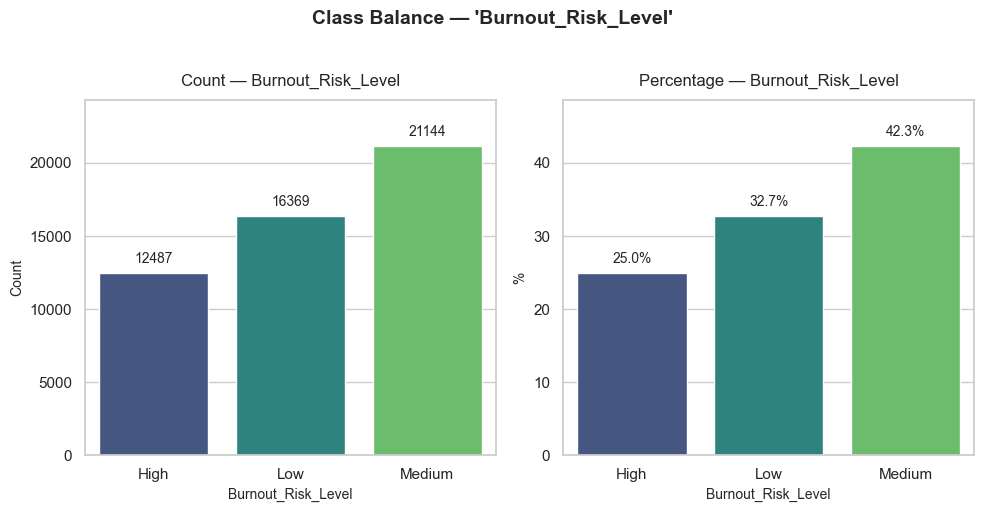

In [20]:
plot_class_balance(df, "Burnout_Risk_Level")

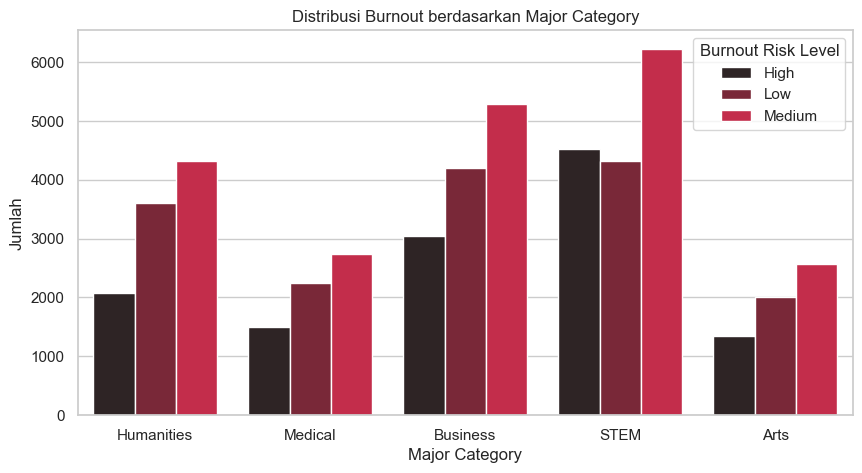

In [9]:
plt.figure(figsize=(10, 5))
sns.countplot(df, x='Major_Category', hue='Burnout_Risk_Level', palette='dark:crimson')
plt.title('Distribusi Burnout berdasarkan Major Category')
plt.xlabel('Major Category')
plt.ylabel('Jumlah')
plt.legend(title='Burnout Risk Level')
plt.show()

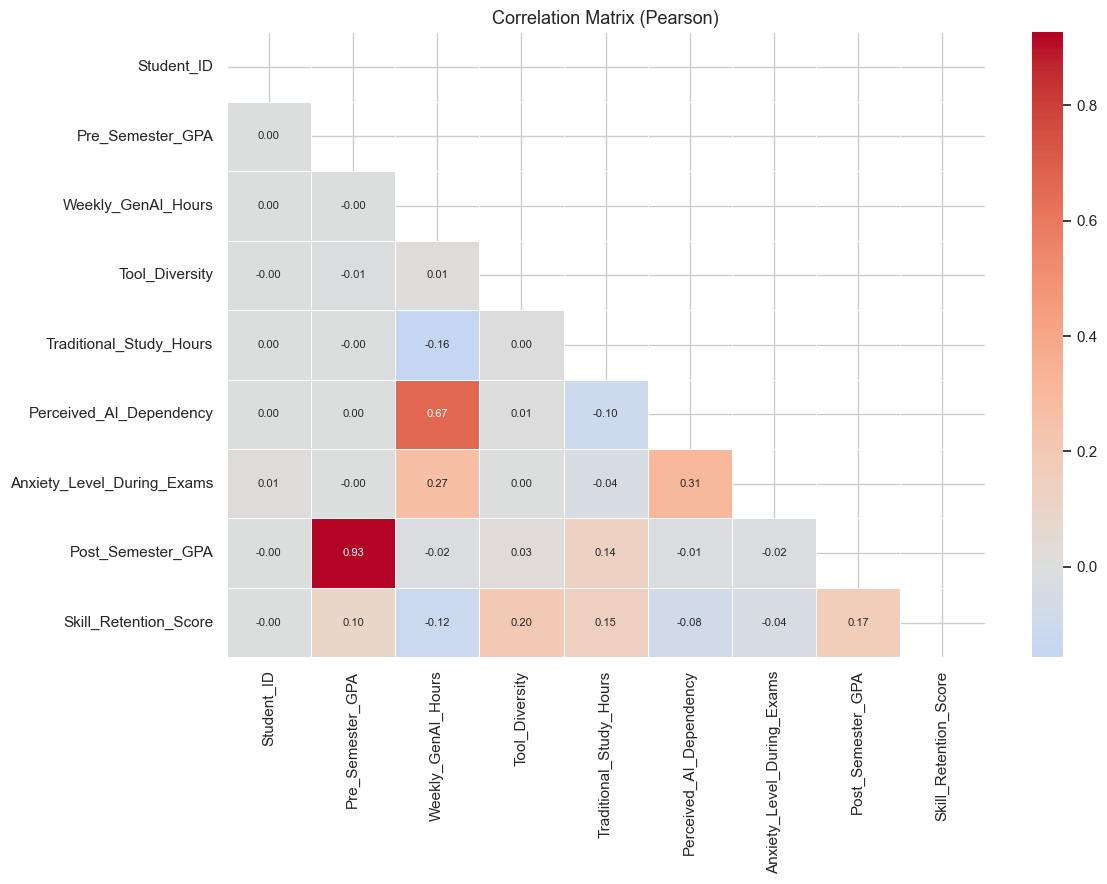

In [15]:
correlation_matrix(df)